In [173]:
import numpy as np
import matplotlib.pyplot as plt

In [174]:
# Params 

Cm = 1.0 
g_na, g_k, g_L = 120, 40, 0.3 
V_na, V_k, V_L = 115, -12, 10.6 

I_app = 0.1
sigma = 0.001  # S/cm
T, T_rest = 0, 0 
#shift = 20

# SPACE SEMI - DISCRETIZATION 

n, L = 100, 1
h = L / n #dx
alpha = sigma / (h**2 * Cm)

p, T = 1000, 25
tau =  T / p  #dt

x = np.linspace(0, L, n)
t = np.linspace(0, T, p)

# condizioni iniziali
V_rest= -65
V = np.ones(n) * V_rest
m_na = 0.05 * np.ones(n)
h_na = 0.6 * np.ones(n)
n_k = 0.32 * np.ones(n)


I_app_vector = np.zeros(n)
I_app_vector[0] = 50  # Stimulus at one end of the fiber


In [175]:

# System building 
def F(V, m_na, h_na, n_k):
    return g_na* m_na**3 * h_na * (V - V_na) + g_k * n_k**4 * (V - V_k) + g_L * (V - V_L)

# Gating Variables
def alpha_m(V): return 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)
def beta_m(V): return 4 * np.exp(-V / 18)

def alpha_h(V): return 0.07 * np.exp(-V / 20)
def beta_h(V): return 1 / (np.exp((30 - V) / 10) + 1)

def alpha_n(V): return 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)
def beta_n(V): return 0.125 * np.exp(-V / 80)


# ---- ricalcolo variabili di gating --------   

def m_new(V, m_na, tau):
    return (m_na + tau * alpha_m(V) * (1 - m_na)) / (1 + tau * beta_m(V))

def h_new(V, h_na, tau):
    return (h_na + tau * alpha_h(V) * (1 - h_na)) / (1 + tau * beta_h(V))

def n_new(V, n_k, tau):
    return (n_k + tau * alpha_n(V) * (1 - n_k)) / (1 + tau * beta_n(V))

In [176]:


def stimulus(step, tau, period, duration):
    """Genera uno stimolo periodico.
    step: Passo temporale corrente.
    tau: Passo temporale.
    period: Periodo tra due impulsi (in ms).
    duration: Durata dell'impulso (in ms).
    """
    impulse_start = int(period / tau)
    impulse_end = impulse_start + int(duration / tau)
    return (step % impulse_start) < impulse_end

for step in range(p):
    # Stimolo periodico
    if stimulus(step, tau, period=0.4, duration=0.2):  # Periodo di 5 ms, durata di 1 ms
        I_app_vector[0] = 50  # μA/cm^2
    else:
        I_app_vector[0] = 0

# -------------------------------------------------------------------------------

# dudt + d2u_dx2 + fu= i_app

# coeff matrix 
M = np.eye(n) 
M[0, 0] = M[-1, -1] = 0.5  # aggiusto con cond Neumann
#M[-1, -2] = M[0,1] = -1

# u_index matrix 
A = np.zeros((n, n))
for i in range(1, n - 1):
    A[i, i] =  2 * alpha
    A[i, i - 1] = - alpha
    A[i, i + 1] = - alpha

# condizioni neumann : derivata nulla agli etsremi dle dominio 
# dvdx =  v1 - v0 / h  = 0 --> v1 = v0
A[0, 0] = A[-1, -1] =  alpha
A[0 , 1] = A[-1, -2] = - alpha

J = M/ tau + A 

#--------------------------------------------------------------------------------


In [177]:

# TIME DISCRETIZATION
# (M/tau + A)*U_n+1 - M/tau*U_n + M*F(U_n) = M*Iapp(n+1)

#------------------------------------------------------------------------------------
# Simulation

v_all = []
m_all = []
h_all = []
n_k_all = []

Ina_all, Ik_all, Il_all = [],[],[]

for step in range(p):
    # Aggiornamento gating variables ad ogni passo
    m = m_new(V, m_na, tau)
    h = h_new(V, h_na, tau)
    n_k = n_new(V, n_k, tau)

    m_na = m.copy()      # Aggiorna m_na, h_na, n_k con lo step prima 
    h_na = h.copy()
    n_k_ = n_k.copy()
    
    I_na = g_na * m_na**3 * h_na * (V - V_na)
    I_k = g_k * n_k**4 * (V - V_k)
    I_L = g_L * (V - V_L)
    I_ion = I_na + I_k + I_L

    # Aggiornamento del potenziale
    rhs_v = (1 /tau) * M @ V - M/Cm @ I_ion + M/Cm @ I_app_vector
    V_new = np.linalg.solve(J, rhs_v)
    V = V_new
    
    # Salva i risultati
    if step % int(p / 30) == 0:
        v_all.append(V.copy())
        m_all.append(m.copy())
        h_all.append(h.copy())
        n_k_all.append(n_k.copy())
        
        Ina_all.append(I_na.copy())
        Ik_all.append(I_k.copy())
        Il_all.append(I_L.copy())

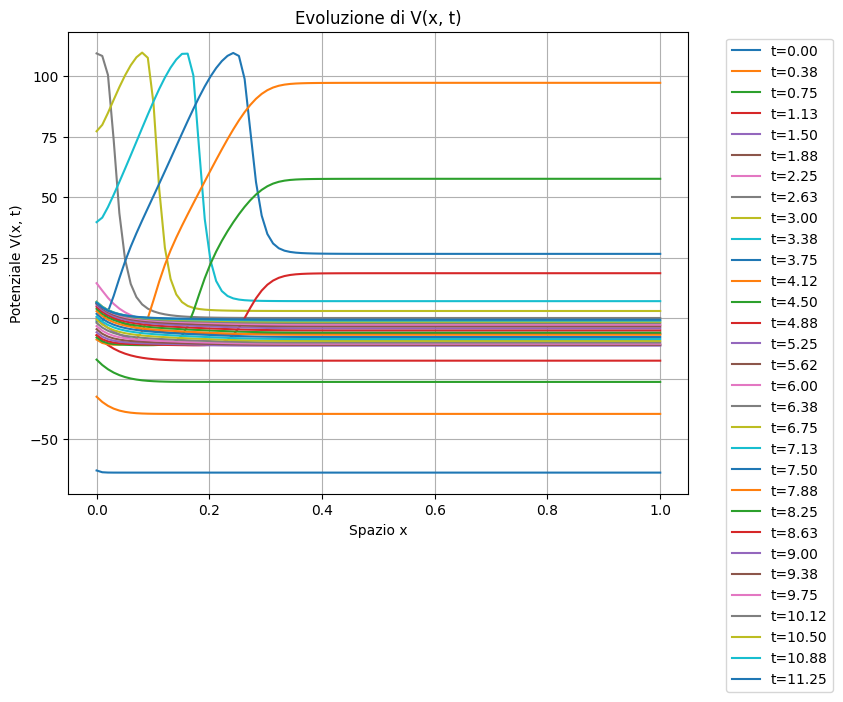

In [178]:
plt.figure(figsize=(8, 6))
for i, v_snapshot in enumerate(v_all):
    plt.plot(x, v_snapshot, label=f"t={i * tau * 15:.2f}")
plt.xlabel("Spazio x")
plt.ylabel("Potenziale V(x, t)")
plt.title("Evoluzione di V(x, t)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()


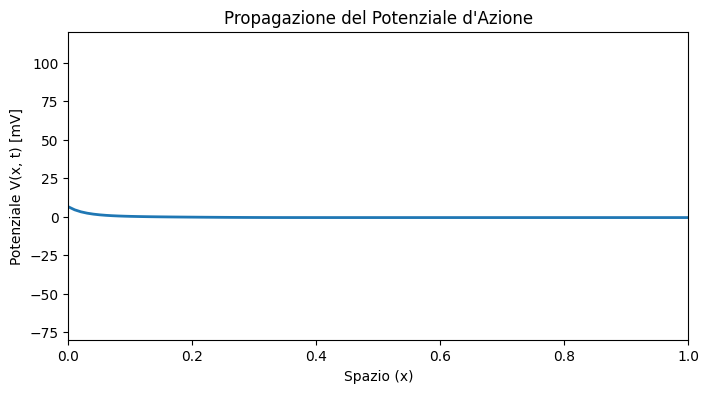

In [179]:
## ANIMATION 

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
from IPython.display import HTML


v_all = np.array(v_all)  # Potenziale V(x, t)

fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 1)  # Spazio lungo la fibra
ax.set_ylim(-80, 120)  # Potenziale di membrana (range tipico)
ax.set_xlabel("Spazio (x)")
ax.set_ylabel("Potenziale V(x, t) [mV]")
ax.set_title("Propagazione del Potenziale d'Azione")

# Funzione per inizializzare l'animazione
def init():
    line.set_data([], [])
    return line,

# Funzione per aggiornare l'animazione ad ogni frame
def update(frame):
    line.set_data(x, v_all[frame])  # Aggiorna il potenziale V(x, t) per il frame corrente
    return line,

# Creazione dell'animazione
ani = FuncAnimation(fig, update, frames=len(v_all), init_func=init, blit=True, interval=50)
HTML(ani.to_jshtml())


In [180]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_data(x, data_dict, title="Animazione", y_label="Valore", ylim= (-80, 120)):
   
    fig, ax = plt.subplots(figsize=(8, 4))
    lines = {}  # Contiene le linee delle variabili
    colors = ["b", "r", "g", "m", "c", "y"]  # Palette colori

    ax.set_xlim(x.min(), x.max())  # Asse X (spaziale)
    ax.set_ylim(ylim)  # Range tipico per il potenziale di membrana
    ax.set_xlabel("Spazio (x)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    # Creazione delle linee per ogni variabile
    for i, (label, values) in enumerate(data_dict.items()):
        lines[label], = ax.plot([], [], lw=2, label=label, color=colors[i % len(colors)])

    ax.legend()

    # Inizializzazione dell'animazione
    def init():
        for line in lines.values():
            line.set_data([], [])
        return lines.values()

    # Funzione di aggiornamento per ogni frame
    def update(frame):
        for label, values in data_dict.items():
            lines[label].set_data(x, values[frame])  # Aggiorna ogni variabile
        return lines.values()

    ani = FuncAnimation(fig, update, frames=len(next(iter(data_dict.values()))), 
                        init_func=init, blit=True, interval=50)

    return HTML(ani.to_jshtml())


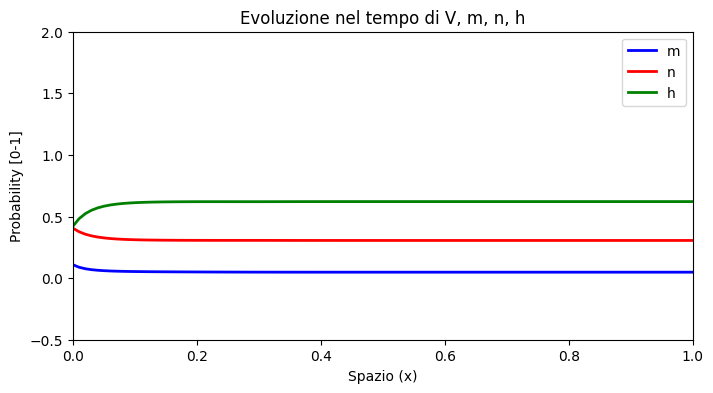

In [181]:
v_all = np.array(v_all)  # Potenziale V(x, t)
m_all = np.array(m_all)
n_k_all = np.array(n_k_all)
h_all = np.array(h_all)

# Converti in array numpy
m_all, n_k_all, h_all = map(np.array, [m_all, n_k_all, h_all])
data_dict = { "m": m_all, "n": n_k_all, "h": h_all}

animate_data(x, data_dict, title="Evoluzione nel tempo di V, m, n, h", y_label="Probability [0-1]", ylim= (-0.5, 2) )

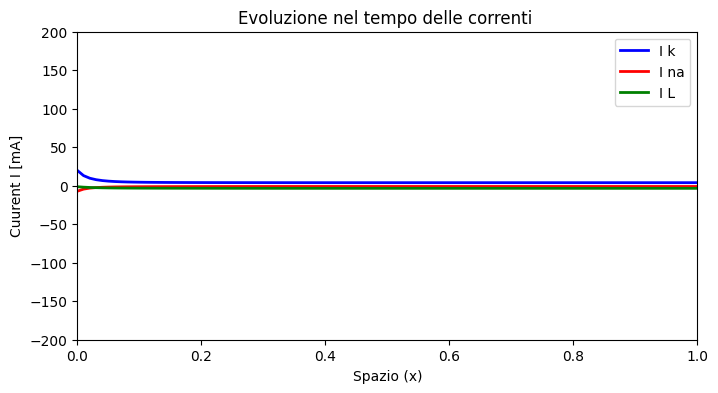

In [182]:
#plot correnti 
Ik_all = np.array(Ik_all)
Ina_all = np.array(Ina_all)
Il_all = np.array(Il_all)

# Converti in array numpy
Ik_all, Ina_all, Il_all = map(np.array, [Ik_all, Ina_all, Il_all])
data_dict = { "I k": Ik_all, "I na": Ina_all, "I L": Il_all}

animate_data(x, data_dict, title="Evoluzione nel tempo delle correnti ", y_label="Cuurent I [mA]", ylim =(-200, 200))


In [183]:


def plot_time_evolution(time, v_all, m_all, n_all, h_all, point_index):
   
    fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

    V_t = v_all[:, point_index]
    m_t = m_all[:, point_index]
    n_t = n_k_all[:, point_index]
    h_t = h_all[:, point_index]

    axes[0].plot(time, V_t, label="V (Potenziale)", color="b")
    axes[1].plot(time, m_t, label="m (Gating Na+)", color="r")
    axes[2].plot(time, n_t, label="n (Gating K+)", color="g")
    axes[3].plot(time, h_t, label="h (Gating Na+)", color="m")
    
    axes[0].set_ylabel("V [mV]")
    axes[1].set_ylabel("m")
    axes[2].set_ylabel("n")
    axes[3].set_ylabel("h")
    axes[3].set_xlabel("Tempo [ms]")

    for ax in axes:
        ax.legend()
        ax.grid(True)

    plt.suptitle(f"Evoluzione temporale delle variabili nel punto x = {point_index}")
    plt.show()



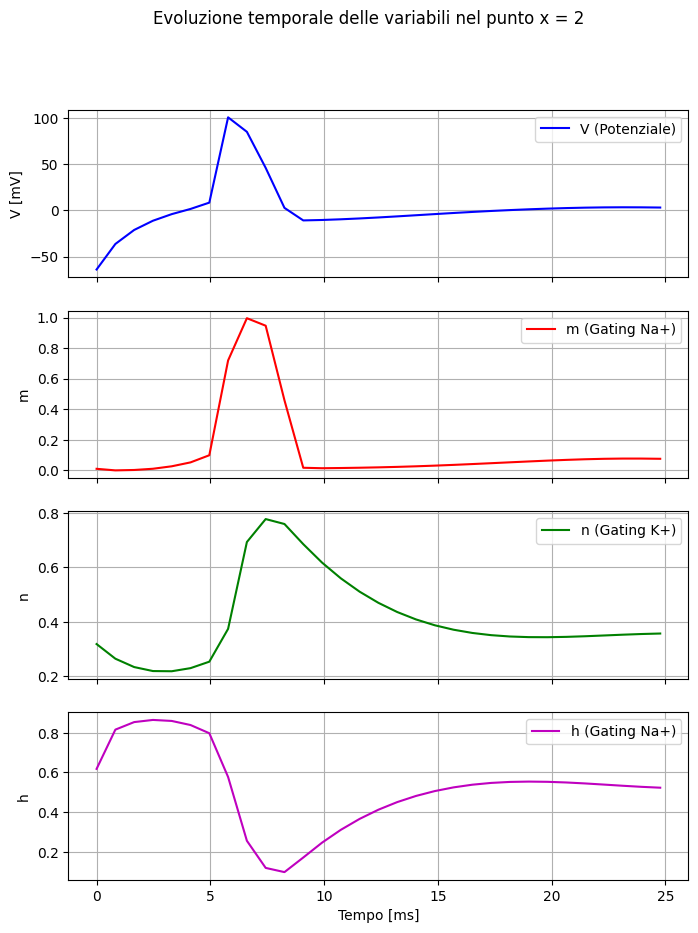

In [184]:
skip = int(len(t) / len(v_all))  # Numero di step saltati tra un salvataggio e l'altro
t2 = t[::(skip+1)]  # Prende solo i punti corrispondenti a v_all

plot_time_evolution(t2, v_all, m_all, n_k_all, h_all, 2)

In [185]:
x1_idx = 10  # Punto iniziale della fibra
x2_idx = 40  # Punto vicino alla fine della fibra
V_th  = 20
# Troviamo il primo tempo in cui V supera la soglia per entrambi i punti
t1_idx = np.where(v_all[:, x1_idx] >= V_th)[0][0]  # Primo tempo in cui supera soglia a x1
t2_idx = np.where(v_all[:, x2_idx] >= V_th)[0][0]  # Primo tempo in cui supera soglia a x2

# Calcoliamo Δx e Δt
delta_x = x[x2_idx] - x[x1_idx]  
delta_t = t[t2_idx] - t[t1_idx]

# Velocità come rapporto Δx/Δt
velocity = delta_x / delta_t  

velocity #units/ ms

6.054545454545455

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


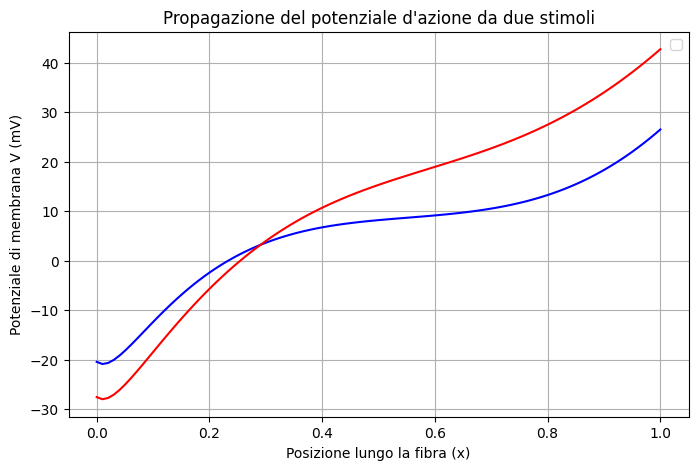

In [187]:
# doppio stimolo

v_all = []
for step in range(p):
    # Aggiorna corrente iniettata per il tempo n+1
    I_app_vector_new = np.zeros(n)  
    I_app_vector_new[0] = 20     # Stimolo al bordo sinistro
    I_app_vector_new[-1] = 20  # Stimolo al bordo destro

    # Calcola il termine di aggiornamento del potenziale V
    rhs_v = (M / tau) @ V - (M/Cm) @ I_ion + (M/Cm) @ I_app_vector_new
    V_new = np.linalg.solve(J, rhs_v)
    V = V_new  

    # Salva i risultati ogni tot passi
    if step % int(p / 35) == 0:
        v_all.append(V.copy())

plt.figure(figsize=(8, 5))
plt.plot(x, v_all[0], color="b")
plt.plot(x, v_all[-1], color="r")
plt.xlabel("Posizione lungo la fibra (x)")
plt.ylabel("Potenziale di membrana V (mV)")
plt.title("Propagazione del potenziale d'azione da due stimoli")
plt.legend()
plt.grid()
plt.show()